In [4]:
!unrar x "/content/drive/MyDrive/NewsImageCNN/dataset/UCF101.rar"

Streaming output truncated to the last 5000 lines.
Extracting  UCF-101/PlayingFlute/v_PlayingFlute_g25_c03.avi               61%  OK 
Extracting  UCF-101/PlayingFlute/v_PlayingFlute_g25_c04.avi               61%  OK 
Extracting  UCF-101/PlayingFlute/v_PlayingFlute_g25_c05.avi               61%  OK 
Extracting  UCF-101/PlayingFlute/v_PlayingFlute_g25_c06.avi               61%  OK 
Extracting  UCF-101/PlayingFlute/v_PlayingFlute_g25_c07.avi               61%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g01_c01.avi             61%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g01_c02.avi             61%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g01_c03.avi             61%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g01_c04.avi             61%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g01_c05.avi             61%  OK 
Extracting  UCF-101/PlayingGu

In [5]:
import os

ucf_path = '/content/UCF-101'
all_classes = sorted(os.listdir(ucf_path))

print(f"Total classes: {len(all_classes)}")
print("\nAll available classes:")
for i, cls in enumerate(all_classes):
    print(f"{i+1:3}. {cls}")

Total classes: 101

All available classes:
  1. ApplyEyeMakeup
  2. ApplyLipstick
  3. Archery
  4. BabyCrawling
  5. BalanceBeam
  6. BandMarching
  7. BaseballPitch
  8. Basketball
  9. BasketballDunk
 10. BenchPress
 11. Biking
 12. Billiards
 13. BlowDryHair
 14. BlowingCandles
 15. BodyWeightSquats
 16. Bowling
 17. BoxingPunchingBag
 18. BoxingSpeedBag
 19. BreastStroke
 20. BrushingTeeth
 21. CleanAndJerk
 22. CliffDiving
 23. CricketBowling
 24. CricketShot
 25. CuttingInKitchen
 26. Diving
 27. Drumming
 28. Fencing
 29. FieldHockeyPenalty
 30. FloorGymnastics
 31. FrisbeeCatch
 32. FrontCrawl
 33. GolfSwing
 34. Haircut
 35. HammerThrow
 36. Hammering
 37. HandstandPushups
 38. HandstandWalking
 39. HeadMassage
 40. HighJump
 41. HorseRace
 42. HorseRiding
 43. HulaHoop
 44. IceDancing
 45. JavelinThrow
 46. JugglingBalls
 47. JumpRope
 48. JumpingJack
 49. Kayaking
 50. Knitting
 51. LongJump
 52. Lunges
 53. MilitaryParade
 54. Mixing
 55. MoppingFloor
 56. Nunchucks
 57. P

In [6]:
import cv2
import os
from tqdm import tqdm

# Paths
ucf_path = '/content/UCF-101'
frames_path = '/content/ucf_frames'
os.makedirs(frames_path, exist_ok=True)

selected_classes = [
    'Basketball',      # was Basketball ✅
    'Biking',          # was Biking ✅
    'Bowling',         # was Bowling ✅
    'CliffDiving',     # was Diving (CliffDiving is better)
    'GolfSwing',       # new - clearly distinct visually
    'HorseRiding',     # was HorseRiding ✅
    'Skiing',          # was Skiing ✅
    'Surfing',         # new - replaces Swimming
    'TennisSwing',     # was Tennis
    'SkateBoarding'    # new - replaces Boxing
]
FRAMES_PER_VIDEO = 16  # extract 16 frames per video

def extract_frames(video_path, output_folder, num_frames=16):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return False

    # Pick evenly spaced frame indices
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved = 0
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in indices:
            frame = cv2.resize(frame, (224, 224))
            cv2.imwrite(os.path.join(output_folder, f'frame_{saved:03d}.jpg'), frame)
            saved += 1
        frame_idx += 1

    cap.release()
    return saved == num_frames

# Extract frames for selected classes
import numpy as np

for cls in selected_classes:
    cls_video_path  = os.path.join(ucf_path, cls)
    cls_frames_path = os.path.join(frames_path, cls)
    os.makedirs(cls_frames_path, exist_ok=True)

    videos = os.listdir(cls_video_path)
    print(f"\nProcessing {cls} — {len(videos)} videos")

    success = 0
    for video in tqdm(videos):
        video_path  = os.path.join(cls_video_path, video)
        video_name  = os.path.splitext(video)[0]
        output_dir  = os.path.join(cls_frames_path, video_name)
        os.makedirs(output_dir, exist_ok=True)

        if extract_frames(video_path, output_dir):
            success += 1

    print(f"  Successfully extracted: {success}/{len(videos)}")

print("\nFrame extraction complete!")


Processing Basketball — 134 videos


100%|██████████| 134/134 [00:06<00:00, 20.71it/s]


  Successfully extracted: 116/134

Processing Biking — 134 videos


100%|██████████| 134/134 [00:11<00:00, 11.92it/s]


  Successfully extracted: 120/134

Processing Bowling — 155 videos


...

  Successfully extracted: 126/126

Processing TennisSwing — 166 videos


100%|██████████| 166/166 [00:08<00:00, 20.33it/s]


  Successfully extracted: 141/166

Processing SkateBoarding — 120 videos


100%|██████████| 120/120 [00:07<00:00, 16.33it/s]

  Successfully extracted: 120/120

Frame extraction complete!


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class VideoFrameDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = sorted(os.listdir(video_path))

        frame_tensors = []
        for frame_file in frames:
            frame_path = os.path.join(video_path, frame_file)
            image      = Image.open(frame_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            frame_tensors.append(image)

        video_tensor = torch.stack(frame_tensors)
        return video_tensor, label

# Build samples list manually
selected_classes = [
    'Basketball', 'Biking', 'Bowling', 'CliffDiving',
    'GolfSwing', 'HorseRiding', 'Skiing', 'Surfing',
    'TennisSwing', 'SkateBoarding'
]

frames_path = '/content/ucf_frames'
class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}

all_samples = []
for cls in selected_classes:
    cls_path = os.path.join(frames_path, cls)
    if not os.path.exists(cls_path):
        print(f"Missing: {cls}")
        continue
    for video_name in os.listdir(cls_path):
        video_path = os.path.join(cls_path, video_name)
        frames     = os.listdir(video_path)
        if len(frames) == 16:
            all_samples.append((video_path, class_to_idx[cls]))

print(f"Total valid videos: {len(all_samples)}")

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Manual train/val split
import random
random.shuffle(all_samples)
split       = int(0.8 * len(all_samples))
train_samples = all_samples[:split]
val_samples   = all_samples[split:]

train_dataset = VideoFrameDataset(train_samples, transform=transform)
val_dataset   = VideoFrameDataset(val_samples,   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Total valid videos: 1328
Train: 1062 | Val: 266


In [8]:
import torch.nn as nn
from torchvision import models

class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=10, hidden_size=512, num_layers=2):
        super(CNN_LSTM, self).__init__()

        # CNN — pretrained ResNet50 as feature extractor
        resnet = models.resnet50(pretrained=True)

        # Freeze everything first
        for param in resnet.parameters():
            param.requires_grad = False

        # Unfreeze ONLY layer4 (last block)
        for name, param in resnet.named_parameters():
            if 'layer4' in name:
                param.requires_grad = True

        # Remove final FC layer
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])

        # Freeze CNN layers
        for param in self.cnn.parameters():
            param.requires_grad = False

        # LSTM — takes CNN features as sequence
        self.lstm = nn.LSTM(
            input_size  = 2048,       # ResNet50 output size
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.3
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x shape: (batch, frames, C, H, W)
        batch_size, frames, C, H, W = x.shape

        # Reshape to process all frames through CNN
        x = x.view(batch_size * frames, C, H, W)

        # CNN feature extraction
        cnn_features = self.cnn(x)  # (batch*frames, 2048, 1, 1)

        cnn_features = cnn_features.view(batch_size, frames, -1)  # (batch, frames, 2048)

        # LSTM temporal modeling
        lstm_out, _ = self.lstm(cnn_features)  # (batch, frames, hidden_size)

        # Take last frame output
        last_output = lstm_out[:, -1, :]  # (batch, hidden_size)

        # Classify
        out = self.classifier(last_output)
        return out

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = CNN_LSTM(num_classes=10).to(device)
print("CNN+LSTM Model ready!")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


CNN+LSTM Model ready!
Trainable parameters: 7,482,122


In [9]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001                    # ← changed
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc    = 0.0
EPOCHS          = 15             # ← changed
checkpoint_path = '/content/drive/MyDrive/NewsImageCNN/checkpoints/cnn_lstm_best.pth'

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            loader = train_loader
        else:
            model.eval()
            loader = val_loader

        running_loss     = 0.0
        running_corrects = 0

        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs        = model(inputs)
                loss           = criterion(outputs, labels)
                _, preds       = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss     += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_corrects.double() / len(loader.dataset)

        print(f"{phase.upper()} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            if epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                torch.save(model.state_dict(), checkpoint_path)
                print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")

print(f"\nTraining Complete! Best Val Acc: {best_val_acc:.4f}")


Epoch 1/15
----------------------------------------
TRAIN — Loss: 1.8292  Acc: 0.4200
VAL — Loss: 0.9928  Acc: 0.8083
  ✅ Best model saved! Val Acc: 0.8083

Epoch 2/15
----------------------------------------
TRAIN — Loss: 0.9234  Acc: 0.7185
VAL — Loss: 0.4953  Acc: 0.8459
  ✅ Best model saved! Val Acc: 0.8459

Epoch 3/15
----------------------------------------
TRAIN — Loss: 0.6153  Acc: 0.8023
VAL — Loss: 0.3180  Acc: 0.9135
  ✅ Best model saved! Val Acc: 0.9135

Epoch 4/15
----------------------------------------
TRAIN — Loss: 0.5005  Acc: 0.8399
VAL — Loss: 0.2737  Acc: 0.9173
  ✅ Best model saved! Val Acc: 0.9173

Epoch 5/15
----------------------------------------
TRAIN — Loss: 0.4944  Acc: 0.8324
VAL — Loss: 0.2010  Acc: 0.9248
  ✅ Best model saved! Val Acc: 0.9248

Epoch 6/15
----------------------------------------
TRAIN — Loss: 0.2167  Acc: 0.9331
VAL — Loss: 0.1887  Acc: 0.9323
  ✅ Best model saved! Val Acc: 0.9323

Epoch 7/15
----------------------------------------
TRAIN

Classification Report:
               precision    recall  f1-score   support

   Basketball       0.85      0.85      0.85        27
       Biking       1.00      1.00      1.00        18
      Bowling       0.96      1.00      0.98        25
  CliffDiving       1.00      0.92      0.96        25
    GolfSwing       0.97      0.97      0.97        33
  HorseRiding       1.00      1.00      1.00        35
       Skiing       0.96      1.00      0.98        23
      Surfing       0.94      1.00      0.97        32
  TennisSwing       0.92      0.96      0.94        25
SkateBoarding       1.00      0.87      0.93        23

     accuracy                           0.96       266
    macro avg       0.96      0.96      0.96       266
 weighted avg       0.96      0.96      0.96       266



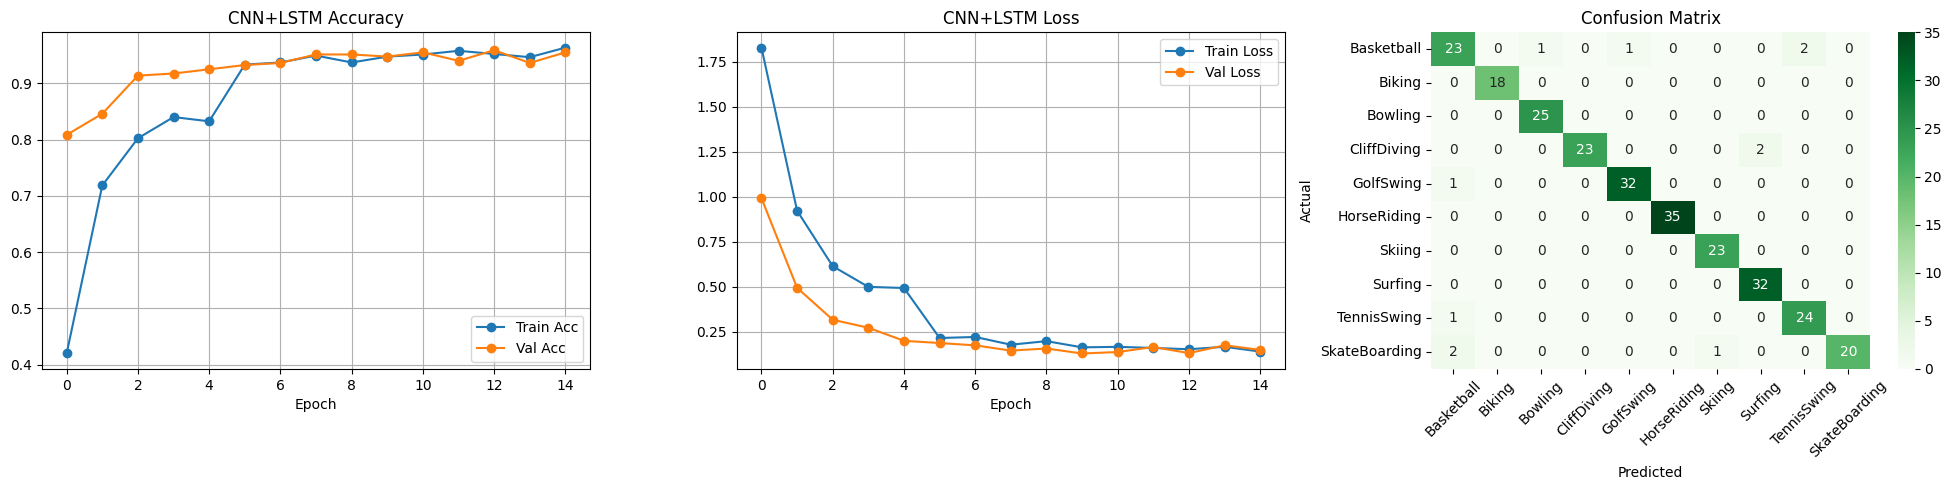

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs  = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=selected_classes))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('CNN+LSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('CNN+LSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=selected_classes,
            yticklabels=selected_classes, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NewsImageCNN/cnn_lstm_results.png', dpi=150)
plt.show()